### Instalación e importación de librerías

In [35]:
# Instalar solo si falta alguna (en Colab ya vienen)
!pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Configurar visualizaciones
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

### Cargar el dataset

In [36]:
# Si el archivo está en el directorio actual
df = pd.read_csv('teen_phone_addiction.csv')
print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
df.head()

Dataset cargado: 3000 filas, 25 columnas


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


### Limpieza y preprocesamiento básico

In [37]:
# Eliminar columnas que no aportan (ID, Name, Location)
df_clean = df.drop(columns=['ID', 'Name', 'Location'], errors='ignore')

# Ver tipos y valores nulos
print("Información del dataset:")
df_clean.info()

print("\nValores nulos por columna:")
print(df_clean.isnull().sum())

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 22 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     3000 non-null   int64  
 1   Gender                  3000 non-null   object 
 2   School_Grade            3000 non-null   object 
 3   Daily_Usage_Hours       3000 non-null   float64
 4   Sleep_Hours             3000 non-null   float64
 5   Academic_Performance    3000 non-null   int64  
 6   Social_Interactions     3000 non-null   int64  
 7   Exercise_Hours          3000 non-null   float64
 8   Anxiety_Level           3000 non-null   int64  
 9   Depression_Level        3000 non-null   int64  
 10  Self_Esteem             3000 non-null   int64  
 11  Parental_Control        3000 non-null   int64  
 12  Screen_Time_Before_Bed  3000 non-null   float64
 13  Phone_Checks_Per_Day    3000 non-null   int64  
 14  Apps_Used_Daily

### Estadísticas descriptivas

In [38]:
# Resumen estadístico de columnas numéricas
df_clean.describe()

,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


### Codificar variables categóricas para correlación

In [39]:
# Identificar columnas categóricas
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Columnas categóricas:", categorical_cols)

# Copia para codificar
df_encoded = df_clean.copy()
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_clean[col].astype(str))
    le_dict[col] = le

# Verificación
df_encoded.head()

Columnas categóricas: ['Gender', 'School_Grade', 'Phone_Usage_Purpose']


,Age,Gender,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,0,5,4.0,6.1,78,5,0.1,10,3,...,1.4,86,19,3.6,1.7,1.2,0,4,8.7,10.0
1,17,0,3,5.5,6.5,70,5,0.0,3,7,...,0.9,96,9,1.1,4.0,1.8,0,2,5.3,10.0
2,13,2,1,5.8,5.5,93,8,0.8,2,3,...,0.5,137,8,0.3,1.5,0.4,1,6,5.7,9.2
3,18,0,2,3.1,3.9,78,8,1.6,9,10,...,1.4,128,7,3.1,1.6,0.8,4,8,3.0,9.8
4,14,2,5,2.5,6.7,56,4,1.1,1,5,...,1.0,96,20,2.6,0.9,1.1,2,10,3.7,8.6


### Matriz de correlación con la variable objetivo

In [40]:
# Calcular correlación con 'Addiction_Level'
target = 'Addiction_Level'
corr_with_target = df_encoded.corr()[target].sort_values(ascending=False)
print("Correlación con el nivel de adicción:")
print(corr_with_target)

# Seleccionar las 10 variables más correlacionadas (positiva o negativamente)
top_features = corr_with_target[1:11]  # excluir el target
print("\nTop 10 características más correlacionadas:")
print(top_features)

Correlación con el nivel de adicción:
Addiction_Level           1.000000
Daily_Usage_Hours         0.600771
Apps_Used_Daily           0.319287
Time_on_Social_Media      0.306578
Time_on_Gaming            0.273060
Phone_Checks_Per_Day      0.246342
Age                       0.031306
Anxiety_Level             0.016005
Screen_Time_Before_Bed    0.013784
Academic_Performance      0.012264
Depression_Level          0.008491
Time_on_Education        -0.000586
Parental_Control         -0.001016
School_Grade             -0.006840
Family_Communication     -0.010482
Social_Interactions      -0.010631
Weekend_Usage_Hours      -0.013049
Phone_Usage_Purpose      -0.017973
Exercise_Hours           -0.021015
Self_Esteem              -0.022292
Gender                   -0.031494
Sleep_Hours              -0.216681
Name: Addiction_Level, dtype: float64

Top 10 características más correlacionadas:
Daily_Usage_Hours         0.600771
Apps_Used_Daily           0.319287
Time_on_Social_Media      0.306578
Time

### Mapa de calor de correlaciones (solo top variables)

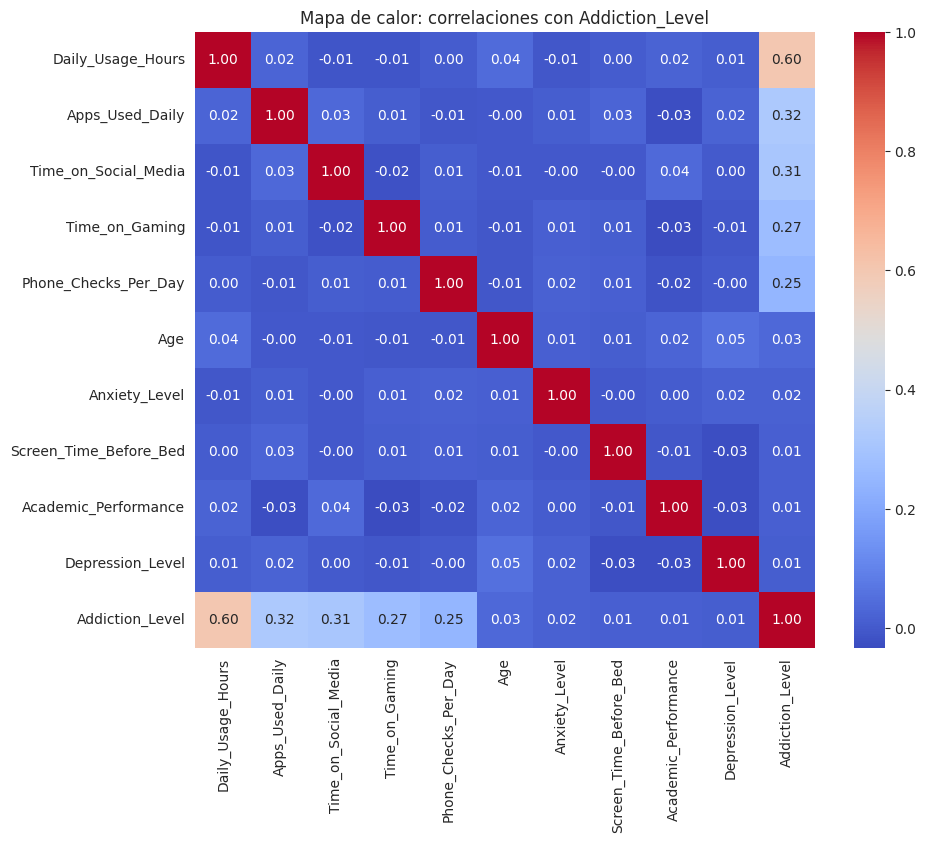

In [41]:
# Tomar las 10 más correlacionadas + el target
top_cols = list(top_features.index) + [target]
plt.figure(figsize=(10,8))
sns.heatmap(df_encoded[top_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mapa de calor: correlaciones con Addiction_Level')
plt.show()

### Distribución de la variable objetivo

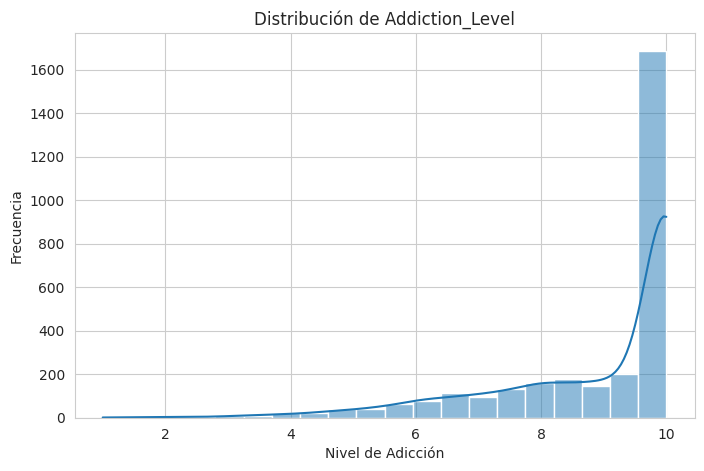

In [42]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean[target], bins=20, kde=True)
plt.title(f'Distribución de {target}')
plt.xlabel('Nivel de Adicción')
plt.ylabel('Frecuencia')
plt.show()

### Boxplots de las principales variables predictoras vs. nivel de adicción (por categorías)

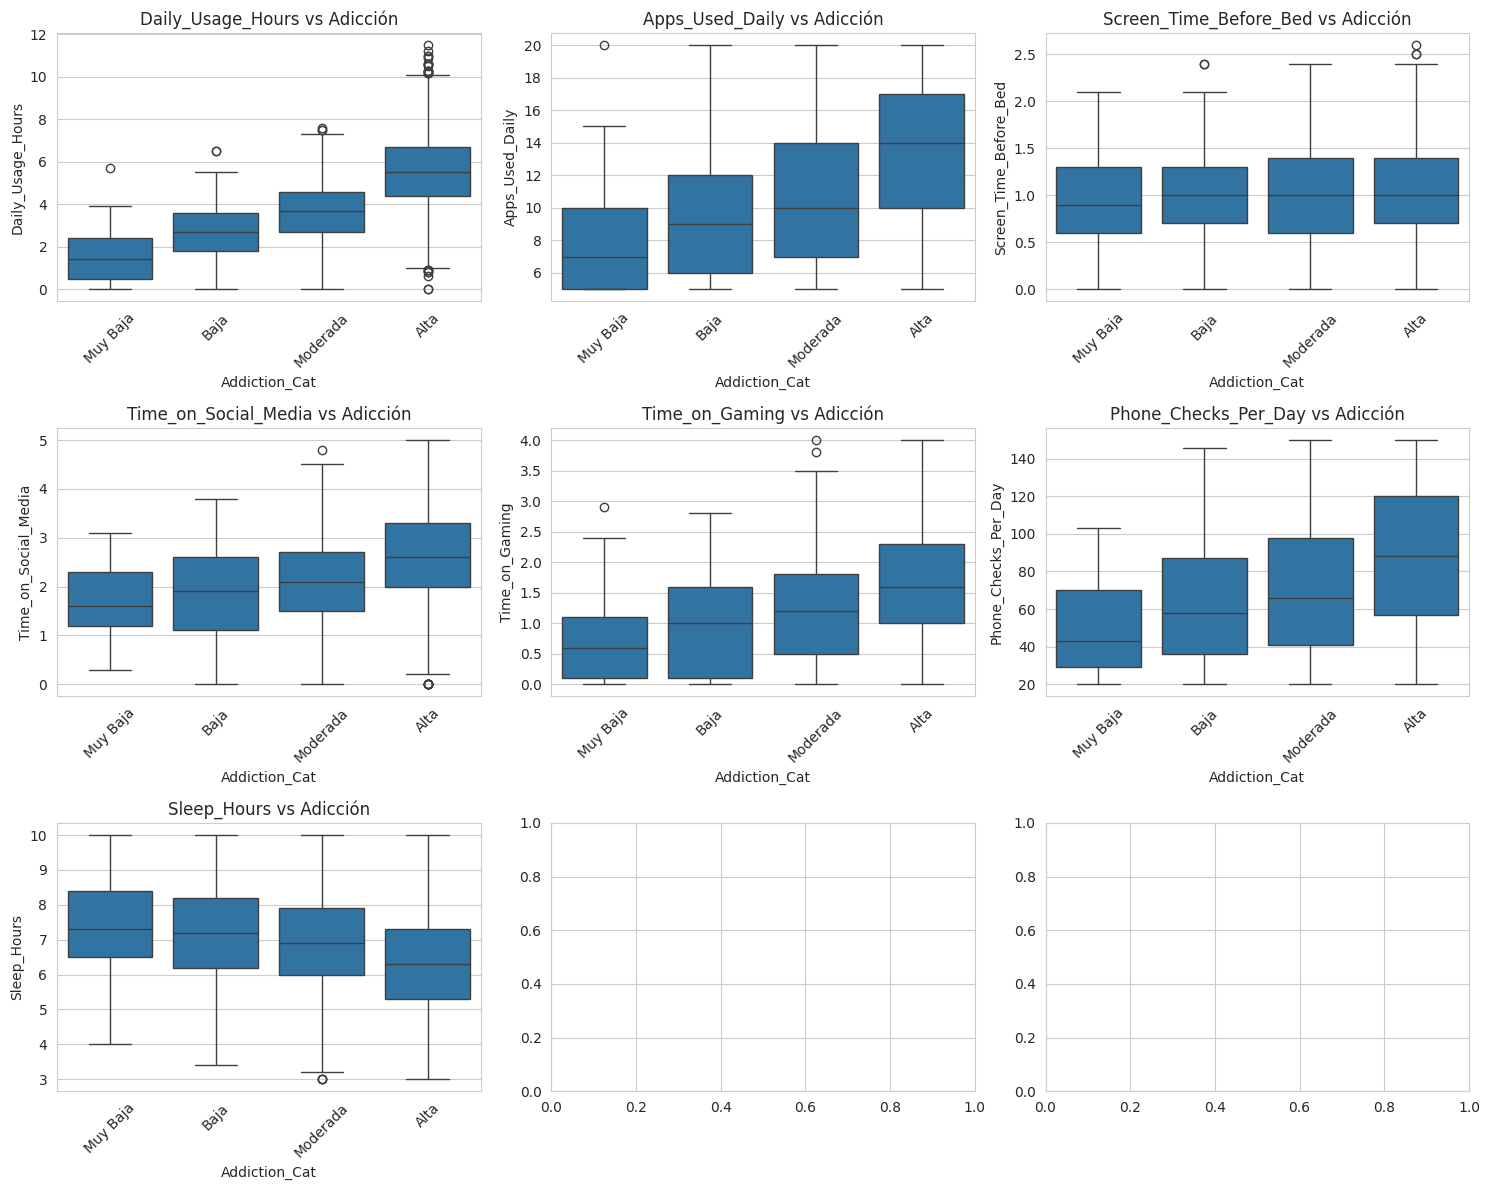

In [43]:
# Crear categorías de adicción
bins = [0, 4, 6, 8, 10.01]
labels = ['Muy Baja', 'Baja', 'Moderada', 'Alta']
df_clean['Addiction_Cat'] = pd.cut(df_clean[target], bins=bins, labels=labels, right=False)

# Seleccionar algunas variables clave (las más correlacionadas)
key_vars = ['Daily_Usage_Hours', 'Apps_Used_Daily', 'Screen_Time_Before_Bed','Time_on_Social_Media', 'Time_on_Gaming', 'Phone_Checks_Per_Day', 'Sleep_Hours']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, var in enumerate(key_vars):
    if i < len(axes):
        sns.boxplot(x='Addiction_Cat', y=var, data=df_clean, ax=axes[i])
        axes[i].set_title(f'{var} vs Adicción')
        axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Scatter plots de las dos variables más correlacionadas

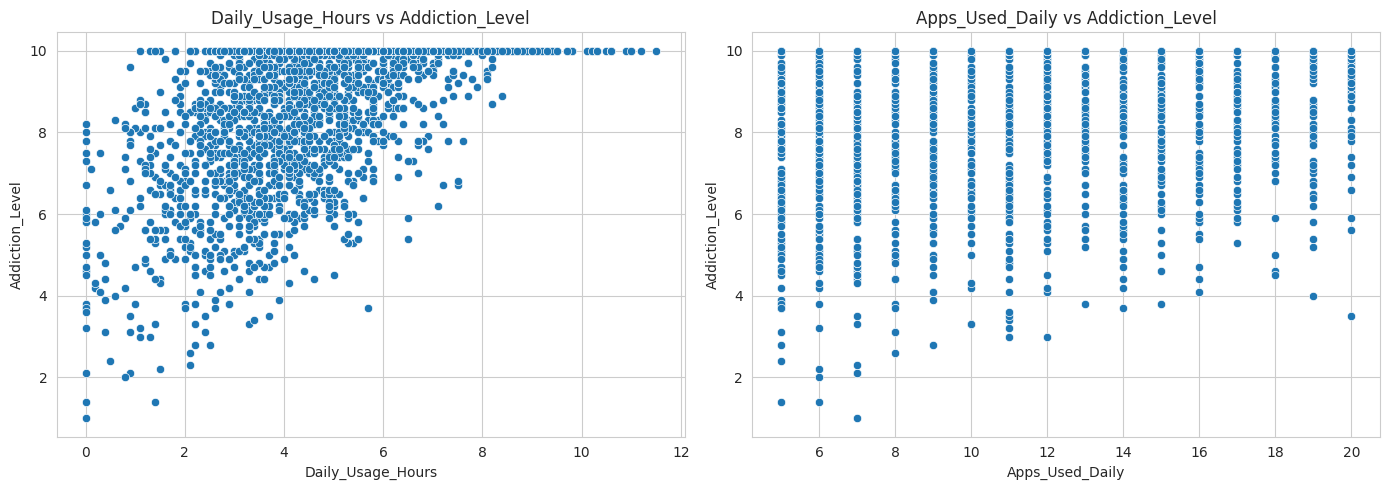

In [44]:
# Tomar las dos primeras de top_features
top1 = top_features.index[0]
top2 = top_features.index[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=top1, y=target, data=df_clean, ax=axes[0])
axes[0].set_title(f'{top1} vs Addiction_Level')
sns.scatterplot(x=top2, y=target, data=df_clean, ax=axes[1])
axes[1].set_title(f'{top2} vs Addiction_Level')
plt.tight_layout()
plt.show()

### Resumen de conclusiones

In [45]:
print("### CONCLUSIONES PRELIMINARES DEL EDA ###")
print(f"1. La variable con mayor correlación positiva con la adicción es: {top_features.index[0]} (corr={top_features.iloc[0]:.3f})")
print(f"2. La segunda es: {top_features.index[1]} (corr={top_features.iloc[1]:.3f})")
print("3. Variables como Sleep_Hours y Self_Esteem tienen correlación negativa (más sueño/autoestima = menos adicción).")
print("4. Esto justifica incluir estas variables en el modelo.")

### CONCLUSIONES PRELIMINARES DEL EDA ###
1. La variable con mayor correlación positiva con la adicción es: Daily_Usage_Hours (corr=0.601)
2. La segunda es: Apps_Used_Daily (corr=0.319)
3. Variables como Sleep_Hours y Self_Esteem tienen correlación negativa (más sueño/autoestima = menos adicción).
4. Esto justifica incluir estas variables en el modelo.
